# MSA 2026 Phase 2 - Part 2: Maximum Temperature Prediction from Weather Data

This project 2 explores relationships between weather variables and builds a regression model to predict **MaxTemp** (maximum daily temperature).

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


## 1. Load and check the dataset

In [5]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/MSA_Phase2/Summary of Weather.csv')

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
display(df.head(10))

Mounted at /content/drive
Shape: 119,040 rows x 31 columns


/tmp/ipykernel_2113/1168243015.py:4: DtypeWarning: Columns (7,8,18,25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/MSA_Phase2/Summary of Weather.csv')


,STA,Date,Precip,WindGustSpd,MaxTemp,MinTemp,MeanTemp,Snowfall,PoorWeather,YR,...,FB,FTI,ITH,PGT,TSHDSBRSGF,SD3,RHX,RHN,RVG,WTE
0,10001,1942-7-1,1.016,NaN,25.555556,22.222222,23.888889,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10001,1942-7-2,0,NaN,28.888889,21.666667,25.555556,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10001,1942-7-3,2.54,NaN,26.111111,22.222222,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10001,1942-7-4,2.54,NaN,26.666667,22.222222,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10001,1942-7-5,0,NaN,26.666667,21.666667,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,10001,1942-7-6,0,NaN,26.666667,21.666667,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,10001,1942-7-7,T,NaN,28.333333,22.777778,25.555556,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,10001,1942-7-8,3.556,NaN,26.666667,22.222222,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,10001,1942-7-9,T,NaN,27.222222,22.777778,25.000000,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,10001,1942-7-10,3.556,NaN,25.555556,21.666667,23.333333,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Column names, data types and missing values
info = pd.DataFrame({
    'Column'   : df.columns,
    'DType'    : df.dtypes.values,
    'Non-Null' : df.notnull().sum().values,
    'Missing'  : df.isnull().sum().values,
    'Missing%' : (df.isnull().mean() * 100).round(1).values
})
display(info)

print("\nDescriptive Statistics:")
display(df.describe().round(2))

,Column,DType,Non-Null,Missing,Missing%
0,STA,int64,119040,0,0.0
1,Date,object,119040,0,0.0
2,Precip,object,119040,0,0.0
3,WindGustSpd,float64,532,118508,99.6
4,MaxTemp,float64,119040,0,0.0
5,MinTemp,float64,119040,0,0.0
6,MeanTemp,float64,119040,0,0.0
7,Snowfall,object,117877,1163,1.0
8,PoorWeather,object,34237,84803,71.2
9,YR,int64,119040,0,0.0



Descriptive Statistics:


,STA,WindGustSpd,MaxTemp,MinTemp,MeanTemp,YR,MO,DA,DR,SPD,...,FT,FB,FTI,ITH,PGT,SD3,RHX,RHN,RVG,WTE
count,119040.00,532.00,119040.00,119040.00,119040.00,119040.00,119040.00,119040.00,533.00,532.00,...,0.0,0.0,0.0,0.0,525.00,0.0,0.0,0.0,0.0,0.0
mean,29659.44,37.77,27.05,17.79,22.41,43.81,6.73,15.80,27.00,20.40,...,NaN,NaN,NaN,NaN,12.09,NaN,NaN,NaN,NaN,NaN
std,20953.21,10.30,8.72,8.33,8.30,1.14,3.43,8.79,15.22,5.56,...,NaN,NaN,NaN,NaN,5.73,NaN,NaN,NaN,NaN,NaN
min,10001.00,18.52,-33.33,-38.33,-35.56,40.00,1.00,1.00,2.00,10.00,...,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN
25%,11801.00,29.63,25.56,15.00,20.56,43.00,4.00,8.00,11.00,16.00,...,NaN,NaN,NaN,NaN,8.50,NaN,NaN,NaN,NaN,NaN
50%,22508.00,37.04,29.44,21.11,25.56,44.00,7.00,16.00,32.00,20.00,...,NaN,NaN,NaN,NaN,11.60,NaN,NaN,NaN,NaN,NaN
75%,33501.00,43.06,31.67,23.33,27.22,45.00,10.00,23.00,34.00,23.25,...,NaN,NaN,NaN,NaN,15.00,NaN,NaN,NaN,NaN,NaN
max,82506.00,75.93,50.00,34.44,40.00,45.00,12.00,31.00,78.00,41.00,...,NaN,NaN,NaN,NaN,23.90,NaN,NaN,NaN,NaN,NaN


## 2. Clean the dataset, drop variables

In [19]:
# Fix Precip column replace 'T' with 0.0
df['Precip'] = df['Precip'].replace('T', 0.0)
df['Precip'] = pd.to_numeric(df['Precip'], errors='coerce')
print("Precip column fixe:d T values replaced with 0.0")

Precip column fixe:d T values replaced with 0.0


In [8]:
# Drop columns with 100% missing: completely empty, no value
fully_missing = [col for col in df.columns
                 if df[col].isnull().mean() * 100 == 100]
print(f"Columns with 100% missing: {fully_missing}")
df.drop(columns=fully_missing, inplace=True)

# Drop non-numerical columns: cannot be used in regression
non_num = df.select_dtypes(exclude='number').columns.tolist()
print(f"\nNon-numerical columns dropped: {non_num}")
df.drop(columns=non_num, inplace=True)

# Drop STA: station ID, not a weather variable
if 'STA' in df.columns:
    df.drop(columns=['STA'], inplace=True)
    print("\nDropped STA — station ID, not a weather variable")

print(f"\nShape after initial drops: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Remaining columns: {list(df.columns)}")

Columns with 100% missing: ['FT', 'FB', 'FTI', 'ITH', 'SD3', 'RHX', 'RHN', 'RVG', 'WTE']

Non-numerical columns dropped: ['Date', 'Snowfall', 'PoorWeather', 'PRCP', 'SNF', 'TSHDSBRSGF']

Dropped STA — station ID, not a weather variable

Shape after initial drops: 119,040 rows x 15 columns
Remaining columns: ['Precip', 'WindGustSpd', 'MaxTemp', 'MinTemp', 'MeanTemp', 'YR', 'MO', 'DA', 'DR', 'SPD', 'MAX', 'MIN', 'MEA', 'SND', 'PGT']


## Correlation Analysis
Before dropping any further columns, we visualize the correlation between all remaining variables and MaxTemp. As this will help us to make decisions about which columns to keep or drop.

Shape for correlation analysis: 524 rows x 15 columns


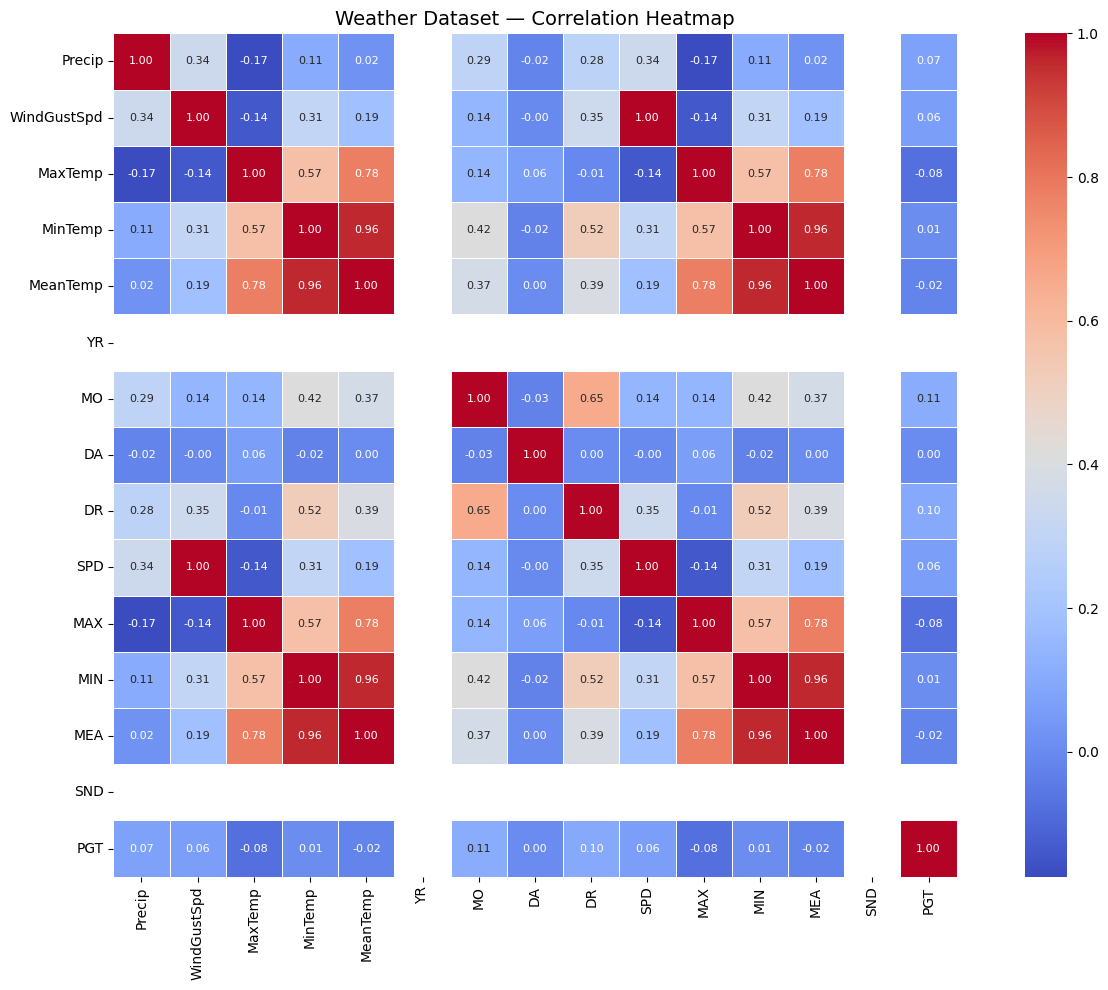

In [9]:
# Temporarily drop NaN rows so heatmap can be computed
df_corr = df.dropna()
print(f"Shape for correlation analysis: {df_corr.shape[0]:,} rows x {df_corr.shape[1]} columns")

corr = df_corr.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, annot_kws={"size": 8})
plt.title('Weather Dataset — Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
# Drop exact duplicates and data leakage columns
leakage = [c for c in ['MeanTemp', 'MAX', 'MIN', 'MEA'] if c in df.columns]
df.drop(columns=leakage, inplace=True)
print(f"Dropped leakage/duplicate columns: {leakage}")
print("Reasoning: MAX is identical to MaxTemp (r=1.00), MEA duplicates")
print("MeanTemp (r=1.00), MIN duplicates MinTemp (r=1.00).")
print("MeanTemp is derived from MaxTemp, keeping it would cause data leakage.")

# Drop near-zero correlation columns
drop_low = [c for c in ['YR', 'DA', 'SND', 'PGT', 'DR'] if c in df.columns]
df.drop(columns=drop_low, inplace=True)
print(f"\nDropped near-zero correlation columns: {drop_low}")
print("Reasoning: YR(r≈0), DA(r=0.06), SND(r≈0), PGT(r=-0.08), DR(r=-0.01)")
print("These features show no meaningful linear relationship with MaxTemp.")

# Drop WindGustSpd and SPD: 99.6% missing values
# Keeping them reduces dataset from 119,040 to just 532 rows
drop_sparse = [c for c in ['WindGustSpd', 'SPD'] if c in df.columns]
df.drop(columns=drop_sparse, inplace=True)
print(f"\nDropped sparse columns: {drop_sparse}")
print("Reasoning: Both had 99.6% missing values — retaining them")
print("would reduce the dataset from 119,040 to just 532 rows (0.4% of data).")

# Drop remaining NaN rows
before = len(df)
df.dropna(inplace=True)
print(f"\nRows dropped due to remaining NaNs: {before - len(df):,}")
print(f"\nFinal shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Remaining columns: {list(df.columns)}")

Dropped leakage/duplicate columns: ['MeanTemp', 'MAX', 'MIN', 'MEA']
Reasoning: MAX is identical to MaxTemp (r=1.00), MEA duplicates
MeanTemp (r=1.00), MIN duplicates MinTemp (r=1.00).
MeanTemp is derived from MaxTemp, keeping it would cause data leakage.

Dropped near-zero correlation columns: ['YR', 'DA', 'SND', 'PGT', 'DR']
Reasoning: YR(r≈0), DA(r=0.06), SND(r≈0), PGT(r=-0.08), DR(r=-0.01)
These features show no meaningful linear relationship with MaxTemp.

Dropped sparse columns: ['WindGustSpd', 'SPD']
Reasoning: Both had 99.6% missing values — retaining them
would reduce the dataset from 119,040 to just 532 rows (0.4% of data).

Rows dropped due to remaining NaNs: 0

Final shape: 119,040 rows x 4 columns
Remaining columns: ['Precip', 'MaxTemp', 'MinTemp', 'MO']


## 3. Select the feature(s) for the model, and explain the reason

 Select Features for the Model

Based on the correlation analysis, the following features are selected
to predict **MaxTemp**:

| Feature | Correlation with MaxTemp | Reasoning |
|---|---|---|
| `MinTemp` | r = +0.57 | Strongest independent predictor available. Minimum and maximum daily temperatures are closely linked, a higher overnight low typically means a higher daytime peak |
| `Precip` | r = -0.17 | Meaningful negative relationship, rainy days tend to have lower maximum temperatures due to cloud cover reducing solar radiation |
| `MO` | r = +0.14 | Captures seasonal temperature patterns, temperatures vary significantly across months of the year |

### Why other features were not selected

| Feature | Reason for Not Selecting |
|---|---|
| `MeanTemp` | Mathematically derived from MaxTemp and MinTemp data leakage possible |
| `MAX, MIN, MEA` | Exact duplicates of MaxTemp, MinTemp, MeanTemp (r=1.00) |
| `WindGustSpd, SPD, DR, PGT` | 99.6% missing values |
| `SND` | 95.3% missing values |
| `Snowfall, PRCP, SNF` | Non-numerical object columns |
| `PoorWeather, TSHDSBRSGF` | 71.2% missing + non-numerical |
| `FT, FB, FTI, ITH, SD3, RHX, RHN, RVG, WTE` | 100% missing |
| `YR, DA, DR` | Near-zero correlation with MaxTemp |
| `STA` | Station ID (not a weather variable) |
| `Date` | Non-numerical (decomposed into MO (month) for seasonality) |

### Limitation
Most useful weather predictors (humidity, cloud cover, atmospheric
pressure, solar radiation) were not present in this dataset.
The selected features are the best available after cleaning.

In [12]:
target   = 'MaxTemp'
features = ['MinTemp', 'Precip', 'MO']

X = df[features]
y = df[target]

print(f"Target   : {target}")
print(f"Features : {features}")
print(f"X shape  : {X.shape}")
print(f"y shape  : {y.shape}")

Target   : MaxTemp
Features : ['MinTemp', 'Precip', 'MO']
X shape  : (119040, 3)
y shape  : (119040,)


## 4. Split the dataset (70% for training, 30% for testing)

## Split Dataset
The dataset is split into:
- **Training set (70%)** >> used to fit the model
- **Test set (30%)** >> used to evaluate performance on unseen data

A random state of 42 is set for reproducibility so results
are consistent across different runs.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

print(f"Total rows   : {len(X):,}")
print(f"Training set : {X_train.shape[0]:,} rows ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test set     : {X_test.shape[0]:,} rows ({len(X_test)/len(X)*100:.0f}%)")

Total rows   : 119,040
Training set : 83,328 rows (70%)
Test set     : 35,712 rows (30%)


## 5. Choose the algorithm, train and test the model


We use **Linear Regression** as our algorithm because:
- `MaxTemp` is a continuous numerical variable, regression is appropriate
- The selected features (MinTemp, Precip, MO) show linear relationships
  with MaxTemp as confirmed by the correlation analysis
- Linear Regression is simple, interpretable, and well suited for
  numerical weather feature prediction
- It works well as a baseline model when feature correlations are moderate

In [14]:
from sklearn.linear_model import LinearRegression

# Initialise and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

print("Model trained successfully.")
print(f"\nModel Coefficients:")
for feat, coef in zip(features, model.coef_):
    print(f"  {feat:10s} : {coef:.4f}")
print(f"\nIntercept: {model.intercept_:.4f}")
print(f"\nInterpretation:")
print(f"  For every 1 unit increase in MinTemp, MaxTemp increases by {model.coef_[0]:.4f}°C")
print(f"  For every 1 unit increase in Precip,  MaxTemp changes by  {model.coef_[1]:.4f}°C")
print(f"  For every 1 unit increase in MO,      MaxTemp changes by  {model.coef_[2]:.4f}°C")

Model trained successfully.

Model Coefficients:
  MinTemp    : 0.9278
  Precip     : -0.0586
  MO         : -0.0684

Intercept: 11.1816

Interpretation:
  For every 1 unit increase in MinTemp, MaxTemp increases by 0.9278°C
  For every 1 unit increase in Precip,  MaxTemp changes by  -0.0586°C
  For every 1 unit increase in MO,      MaxTemp changes by  -0.0684°C


## 6. Evaluate and Visualize model Performance

## Evaluating and Visualising Model Performance

We evaluate the model using two metrics:
- **R²** : measures how well the model explains variance in MaxTemp
- **RMSE** : measures average prediction error in degrees

In [15]:
from sklearn.metrics import r2_score, mean_squared_error

r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²   : {r2:.4f}")
print(f"RMSE : {rmse:.4f}°C")
print(f"\nThe model explains {r2*100:.1f}% of the variance in MaxTemp.")
print(f"Predictions are off by an average of {rmse:.2f}°C.")

R²   : 0.7773
RMSE : 4.0963°C

The model explains 77.7% of the variance in MaxTemp.
Predictions are off by an average of 4.10°C.


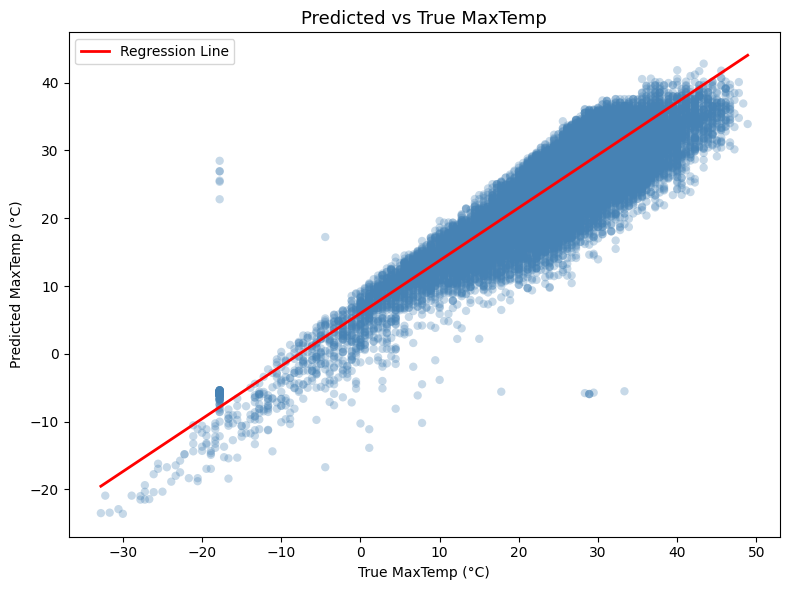

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3,
            color='steelblue', edgecolors='none')

# Regression line through the predicted points
m, b = np.polyfit(y_test, y_pred, 1)
x_line = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(x_line, m * x_line + b,
         color='red', linewidth=2, label=f'Regression Line')

plt.title('Predicted vs True MaxTemp', fontsize=13)
plt.xlabel('True MaxTemp (°C)')
plt.ylabel('Predicted MaxTemp (°C)')
plt.legend()
plt.tight_layout()
plt.show()

## 7. What is the R² value and RMSE of the model? How these values indicate the model performance?

## Understanding R² and RMSE

**R² (R-squared) = 0.7773**
- Measures how much of the variance in MaxTemp is explained by the model
- Range: 0 to 1 (higher the number is better prediction)
- R² = 1.0 >>  perfect prediction
- R² = 0.0 >> model explains none of the variance
- Our R² = 0.7773 means the model explains **77.7% of the variance**
  in MaxTemp using just 3 features (MinTemp, Precip, MO)

**RMSE (Root Mean Squared Error) = 4.0963°C**
- Measures average prediction error in the same units as MaxTemp (°C)
- Lower is better
- Our RMSE = 4.10°C means predictions are off by an average of **4.10°C**
- RMSE penalises large errors more heavily than small ones due to squaring
- For weather prediction, 4.10°C error is moderate, acceptable because
  only 3 features were available after cleaning

## 8. Discuss the model performance based on the plot

## Step 8: Discuss Model Performance

### Results
| Metric | Value | Interpretation |
|---|---|---|
| R² | 0.7773 | Model explains 77.7% of MaxTemp variance |
| RMSE | 4.0963°C | Average prediction error of 4.10°C |

### Discussion

**Overall performance:**
The model performed well given only 3 features were available after cleaning. An R² of 0.7773 indicates a strong fit, the model captures 77.7% of the variation in daily maximum temperature.

**Predicted vs True plot observations:**
- The points form a clear diagonal band following the regression line,
  confirming a strong positive linear relationship between predicted
  and true MaxTemp values
- The regression line runs close to diagonal, indicating the model
  predictions are well aligned with actual values across the full
  temperature range (-30°C to +50°C)
- Spread around the regression line is relatively consistent across
  the temperature range, suggesting no major systematic bias
- A small cluster of anomalous points is visible around True MaxTemp
  = -20°C with predicted values around -5°C, these may represent
  extreme cold weather days where the model underestimates the cold
- A few isolated outlier points appear around True MaxTemp = 30°C
  with very low predicted values (~-5°C), these could be due to presence of
  anomalies in the original dataset

**Key driver:**
MinTemp (coefficient = 0.9278) is the dominant predictor. The strong
relationship between minimum and maximum daily temperature drives most
of the model's predictive power (r = +0.57).

**Limitations:**
- Only 3 features available after cleaning, key weather variables
  such as humidity, cloud cover and atmospheric pressure were absent
- RMSE of 4.10°C means some predictions could be significantly off
  for extreme temperature days as seen in the outlier clusters
- Linear Regression assumes linear relationships, the outlier
  clusters suggest some non-linear patterns exist in the data
- A more complex model such as Random Forest or Gradient Boosting
  may better handle the outliers and non-linear patterns

**Conclusion:**
Despite the limited feature set, the Linear Regression model achieved
a strong R² of 0.7773, demonstrating that MinTemp is a reliable
predictor of MaxTemp. The model provides a solid baseline for
weather temperature prediction with room for improvement through
additional features or more advanced algorithms.